<a href="https://colab.research.google.com/github/epjf99-rgb/Entregas/blob/main/ProyectoContingencia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

***Equipo Icarus***

Edgar Antonio Arteaga Rico

Andrea García Juárez

Diego Amaury Hernández Sanabria

Julio César López Mendoza

Eduardo Javier Peralta Flores

Diego Villarreal Araiza

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.neural_network import MLPRegressor
import seaborn as sns
from sklearn.model_selection import train_test_split

In [ ]:
O3 = pd.read_csv('Datos SINAICA-O3-CH.csv',encoding = 'latin1')

In [ ]:
O3

,Parámetro,Fecha,Hora,ACO : Acolman,AJU : Ajusco,AJM : Ajusco Medio,ATI : Atizapán,CAM : Camarones,CCA : Centro de Ciencias de la Atmósfera,CHO : Chalco,...,PLA : Plateros,TAC : Tacuba,TAX : Taxqueña,TPN : Tlalpan,MIN : Metro Insurgentes,SUR : Santa Ursula,VAL : Vallejo,FAR : FES Aragón,SAC : Santiago Acahualtepec,Unidad
0,O3,1/1/2021,0,- - - -,0.024,- - - -,0.023,0.009,0.007,- - - -,...,- - - -,- - - -,- - - -,- - - -,- - - -,- - - -,- - - -,0.018,0.02,ppm
1,O3,1/1/2021,1,- - - -,0.025,- - - -,0.012,0,0.008,- - - -,...,- - - -,- - - -,- - - -,- - - -,- - - -,- - - -,- - - -,0.02,0.021,ppm
2,O3,1/1/2021,2,- - - -,0.024,- - - -,0.009,0.001,0.007,- - - -,...,- - - -,- - - -,- - - -,- - - -,- - - -,- - - -,- - - -,0.016,0.019,ppm
3,O3,1/1/2021,3,- - - -,0.023,- - - -,0.004,0,0.006,- - - -,...,- - - -,- - - -,- - - -,- - - -,- - - -,- - - -,- - - -,0.013,0.019,ppm
4,O3,1/1/2021,4,- - - -,0.025,- - - -,0.003,0.003,0.003,- - - -,...,- - - -,- - - -,- - - -,- - - -,- - - -,- - - -,- - - -,0.013,0.01,ppm
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26275,O3,12/31/2023,19,- - - -,0.037,0.052,0.016,0.015,0.024,0.04,...,- - - -,- - - -,- - - -,- - - -,- - - -,- - - -,- - - -,0.022,0.042,ppm
26276,O3,12/31/2023,20,- - - -,0.033,0.043,0.021,0.005,0.021,0.032,...,- - - -,- - - -,- - - -,- - - -,- - - -,- - - -,- - - -,0.019,0.036,ppm
26277,O3,12/31/2023,21,- - - -,0.019,0.032,0.018,0.002,0.011,0.022,...,- - - -,- - - -,- - - -,- - - -,- - - -,- - - -,- - - -,0.017,0.031,ppm
26278,O3,12/31/2023,22,- - - -,0.012,0.04,0.013,0.002,0.002,0.022,...,- - - -,- - - -,- - - -,- - - -,- - - -,- - - -,- - - -,0.008,0.035,ppm


In [ ]:
O3 = O3.iloc[:,1:]
O3.index = O3.iloc[:,0]
O3.index = pd.to_datetime(O3.index)
O3 = O3.iloc[:,3:53]
for col in O3.columns:
    O3[col] = O3[col].replace(" - - - - ",np.nan)
    O3[col] = pd.to_numeric(O3[col], errors='coerce')

<ipython-input-243-bfaee45fe134>:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  O3[col] = O3[col].replace(" - - - - ",np.nan)


In [ ]:
for col in O3.columns[3:54]:
    if(O3[col].sum()==0):
        O3 = O3.drop(col, axis=1)

In [ ]:
O3

,AJU : Ajusco,AJM : Ajusco Medio,ATI : Atizapán,CAM : Camarones,CCA : Centro de Ciencias de la Atmósfera,CHO : Chalco,CUA : Cuajimalpa,CUT : Cuautitlán,FAC : FES Acatlán,HGM : Hospital General de México,...,UIZ : UAM Iztapalapa,UAX : UAM Xochimilco,VIF : Villa de las Flores,XAL : Xalostoc,MPA : Milpa Alta,BJU : Benito Juárez,INN : Instituto Nacional de Investigaciones Nucleares,GAM : Gustavo A. Madero,FAR : FES Aragón,SAC : Santiago Acahualtepec
Fecha,,,,,,,,,,,,,,,,,,,,,
2021-01-01,0.024,NaN,0.023,0.009,0.007,NaN,NaN,0.001,0.025,NaN,...,0.021,0.025,0.002,NaN,0.038,0.002,0.040,0.006,0.018,0.020
2021-01-01,0.025,NaN,0.012,0.000,0.008,NaN,NaN,0.001,0.019,NaN,...,0.008,0.015,0.002,NaN,0.037,0.002,0.037,0.010,0.020,0.021
2021-01-01,0.024,NaN,0.009,0.001,0.007,NaN,NaN,0.005,0.009,NaN,...,0.011,0.012,0.004,NaN,0.037,0.006,0.037,0.006,0.016,0.019
2021-01-01,0.023,NaN,0.004,0.000,0.006,NaN,NaN,0.004,0.009,NaN,...,0.006,0.008,0.006,NaN,0.038,0.003,0.041,0.002,0.013,0.019
2021-01-01,0.025,NaN,0.003,0.003,0.003,NaN,NaN,0.002,0.005,NaN,...,0.006,0.008,0.005,NaN,0.038,0.006,0.037,0.002,0.013,0.010
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-31,0.037,0.052,0.016,0.015,0.024,0.040,0.024,0.020,0.006,0.033,...,0.040,NaN,NaN,0.027,0.050,0.036,NaN,NaN,0.022,0.042
2023-12-31,0.033,0.043,0.021,0.005,0.021,0.032,0.031,0.019,0.009,0.016,...,0.016,NaN,NaN,0.020,0.051,0.024,NaN,NaN,0.019,0.036
2023-12-31,0.019,0.032,0.018,0.002,0.011,0.022,0.029,0.007,0.016,0.004,...,0.003,NaN,NaN,0.014,0.040,0.006,NaN,NaN,0.017,0.031


In [ ]:
O3 = O3.groupby(O3.index).max()
O3

,AJU : Ajusco,AJM : Ajusco Medio,ATI : Atizapán,CAM : Camarones,CCA : Centro de Ciencias de la Atmósfera,CHO : Chalco,CUA : Cuajimalpa,CUT : Cuautitlán,FAC : FES Acatlán,HGM : Hospital General de México,...,UIZ : UAM Iztapalapa,UAX : UAM Xochimilco,VIF : Villa de las Flores,XAL : Xalostoc,MPA : Milpa Alta,BJU : Benito Juárez,INN : Instituto Nacional de Investigaciones Nucleares,GAM : Gustavo A. Madero,FAR : FES Aragón,SAC : Santiago Acahualtepec
Fecha,,,,,,,,,,,,,,,,,,,,,
2021-01-01,0.063,NaN,0.060,0.063,0.069,NaN,NaN,0.081,0.073,NaN,...,0.062,0.053,0.067,NaN,0.060,0.057,0.048,0.064,0.059,0.044
2021-01-02,0.070,NaN,0.072,0.086,0.094,NaN,NaN,0.083,0.081,NaN,...,0.103,0.084,0.084,NaN,0.101,0.072,0.054,0.092,0.087,0.070
2021-01-03,0.058,NaN,0.065,0.075,0.076,NaN,NaN,0.079,0.077,NaN,...,0.068,0.070,0.094,NaN,0.058,0.057,0.049,0.069,0.067,0.042
2021-01-04,0.085,NaN,0.064,0.079,0.097,NaN,NaN,0.065,0.080,NaN,...,0.092,0.085,0.072,NaN,0.067,0.067,0.054,0.084,0.090,0.063
2021-01-05,0.060,NaN,0.077,0.088,0.100,NaN,NaN,0.091,0.096,NaN,...,0.085,0.071,0.090,NaN,0.069,0.069,0.053,0.090,0.085,0.050
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-27,0.033,0.034,0.014,0.024,0.028,0.021,0.030,0.024,0.015,0.028,...,0.028,NaN,NaN,0.015,0.034,0.029,NaN,0.015,0.016,0.031
2023-12-28,0.069,0.075,0.053,0.068,0.064,0.047,0.063,0.074,0.070,0.070,...,0.057,NaN,NaN,0.060,0.056,0.076,NaN,0.057,0.047,0.055
2023-12-29,0.062,0.069,0.043,0.068,0.067,0.041,0.068,0.063,0.058,0.065,...,0.057,NaN,NaN,0.057,0.056,0.070,NaN,0.057,0.041,0.054


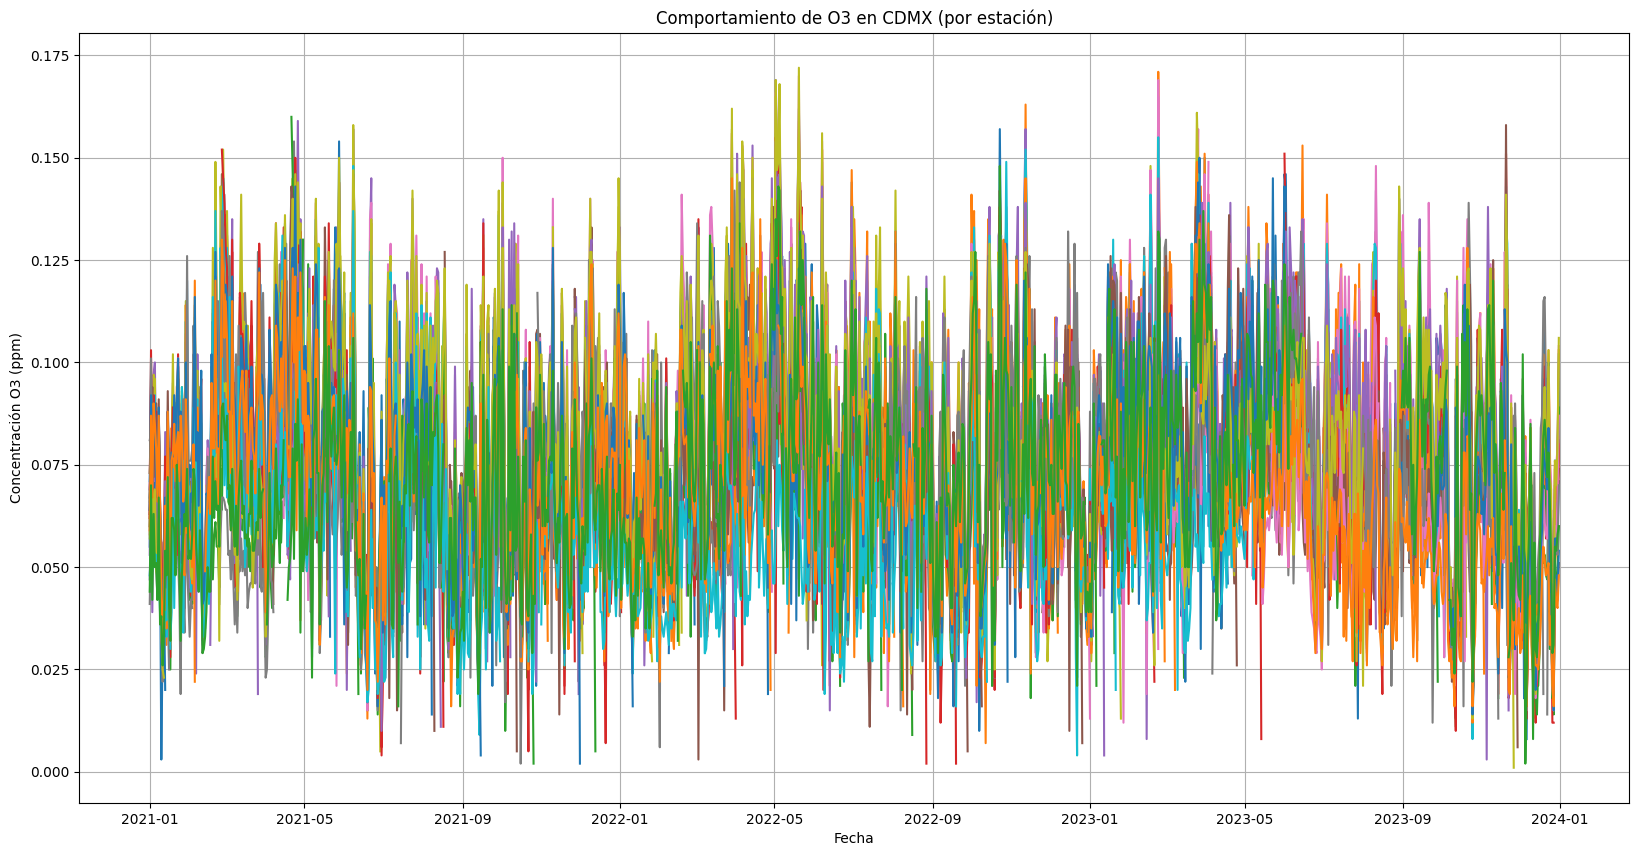

In [ ]:
fig,ax = plt.subplots(figsize=(20,10))
plt.plot(O3)
plt.grid()
ax.set_xlabel("Fecha")
ax.set_ylabel("Concentración O3 (ppm)")
ax.set_title("Comportamiento de O3 en CDMX (por estación)")
plt.show()

In [ ]:
O3max = O3.max(axis=1)
O3max

,0
Fecha,
2021-01-01,0.081
2021-01-02,0.103
2021-01-03,0.094
2021-01-04,0.097
2021-01-05,0.100
...,...
2023-12-27,0.034
2023-12-28,0.076
2023-12-29,0.075


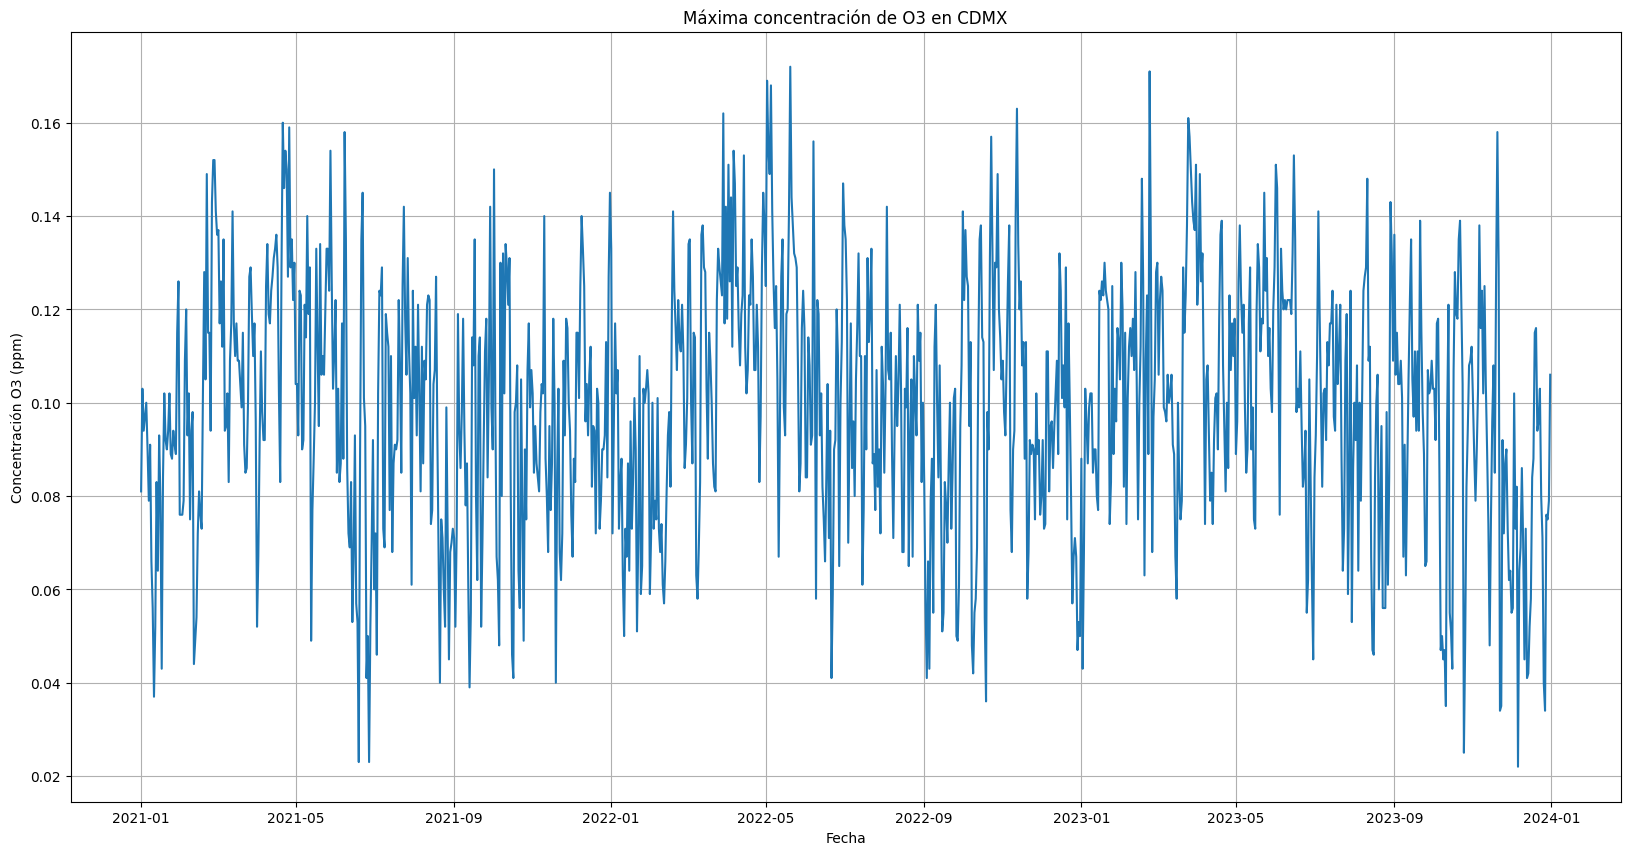

In [ ]:
fig,ax = plt.subplots(figsize=(20,10))
plt.plot(O3max)
plt.grid()
ax.set_xlabel("Fecha")
ax.set_ylabel("Concentración O3 (ppm)")
ax.set_title("Máxima concentración de O3 en CDMX")
plt.show()

In [ ]:
O3_rs = O3max.resample("1d").mean()

In [ ]:
x = O3_rs.copy()
y = O3_rs.copy()

In [ ]:
X=pd.DataFrame(x)
X["t-1"] = X.shift(1)
for i in range(1,5):
  X["t-"+str(i+1)] = X["t-"+str(i)].shift(1)
X = X.iloc[:,1:]
X = X.dropna()
Y = y.iloc[5:]

In [ ]:
fecha = "2023-12-31"

Xtrain = X.loc[:fecha]
Xtest = X.loc[fecha:]
Ytrain = Y.loc[:fecha]
Ytest = Y.loc[fecha:]

In [ ]:
red = MLPRegressor(hidden_layer_sizes=(100,100), activation = "relu",max_iter = 10000)
red.fit(Xtrain,Ytrain)
red.score(X,Y)

0.220653766294016

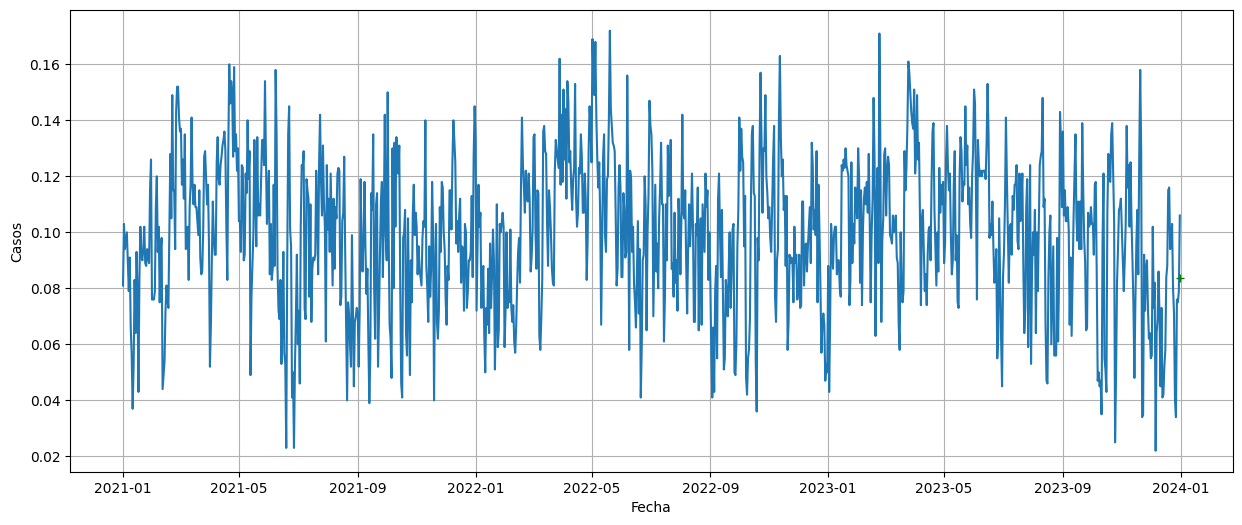

In [ ]:
fig, ax = plt.subplots(figsize=(15, 6))
plt.grid()
plt.plot(y)
plt.plot(Xtest.index,red.predict(Xtest),"g+")
ax.set_xlabel("Fecha")
ax.set_ylabel("Máxima concentración de O3 en CDMX")
plt.show()

In [ ]:
n = 0
Xp = Xtrain.copy()
Xp = Xp.iloc[len(Xp.index)-1:len(Xp.index)]
while n<5:
  Xant = Xp.iloc[len(Xp.index)-1:len(Xp.index)]
  Xp1 = Xant.shift(1,axis=1)
  Xp1["t-1"] = red.predict(Xant)
  Xp1.index = Xant.index + pd.Timedelta(days=1)
  Xp = pd.concat([Xp,Xp1])
  n+=1

Xp

,t-1,t-2,t-3,t-4,t-5
Fecha,,,,,
2023-12-31,0.079000,0.075000,0.076000,0.034000,0.040000
2024-01-01,0.083841,0.079000,0.075000,0.076000,0.034000
2024-01-02,0.084689,0.083841,0.079000,0.075000,0.076000
2024-01-03,0.087149,0.084689,0.083841,0.079000,0.075000
2024-01-04,0.088000,0.087149,0.084689,0.083841,0.079000
2024-01-05,0.088621,0.088000,0.087149,0.084689,0.083841


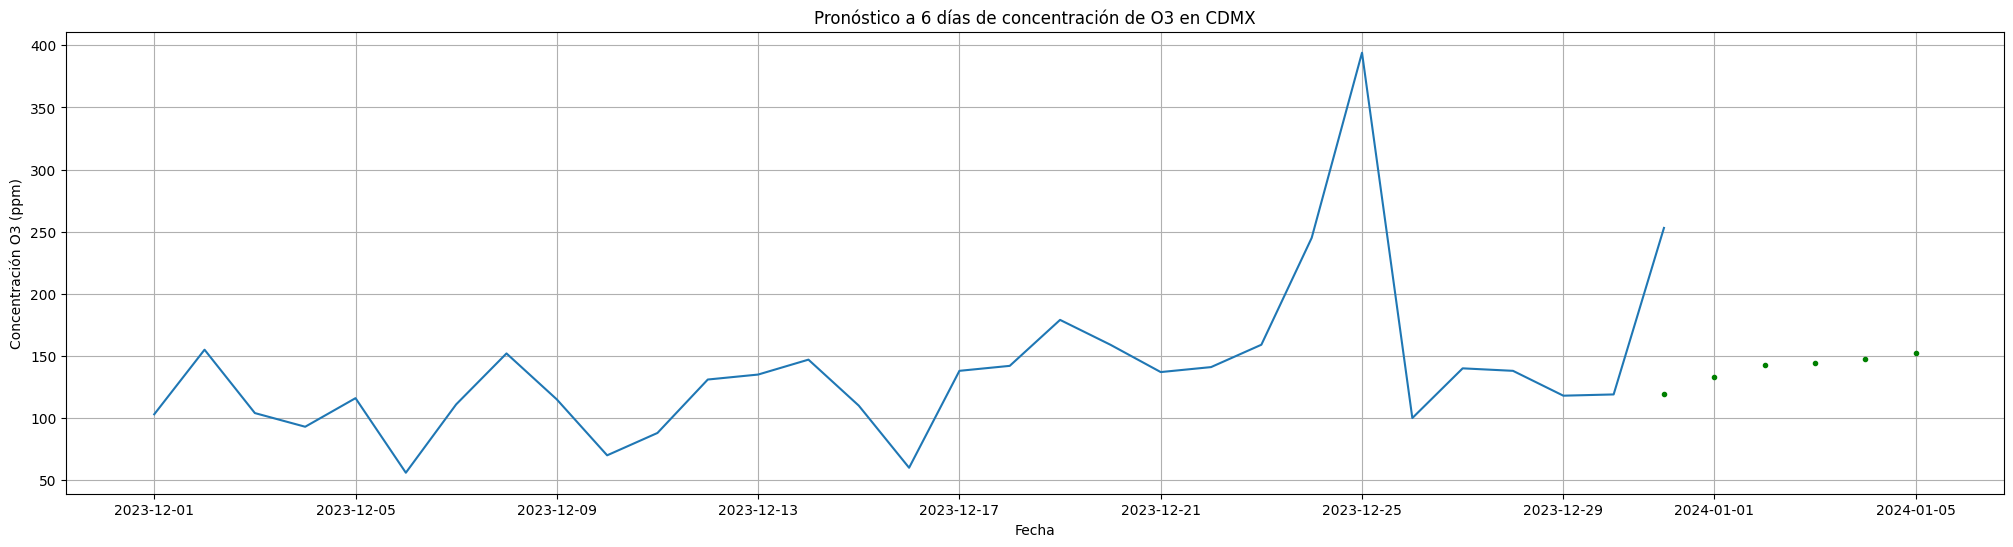

In [ ]:
fig, ax = plt.subplots(figsize=(25, 6))
plt.grid()
plt.plot(y["2023-12-01":"2024-01-28"])
plt.plot(Xp["2023-12-01":"2024-01-28"].index,Xp["2023-12-01":"2024-01-28"]["t-1"],"g.")
ax.set_title("Pronóstico a 6 días de concentración de O3 en CDMX")
ax.set_xlabel("Fecha")
ax.set_ylabel("Concentración O3 (ppm)")
plt.show()

In [ ]:
PM25 = pd.read_csv('Datos SINAICA-PM2.5-CH.csv',encoding = 'latin1')

In [ ]:
PM25 = PM25.iloc[:,1:]
PM25.index = PM25.iloc[:,0]
PM25.index = pd.to_datetime(PM25.index)
PM25 = PM25.iloc[:,3:53]
for col in PM25.columns:
    PM25[col] = PM25[col].replace(" - - - - ",np.nan)
    PM25[col] = pd.to_numeric(PM25[col], errors='coerce')

<ipython-input-259-12cf7cd93f99>:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  PM25[col] = PM25[col].replace(" - - - - ",np.nan)


In [ ]:
for col in PM25.columns[3:54]:
    if(PM25[col].sum()==0):
        PM25 = PM25.drop(col, axis=1)

In [ ]:
PM25 = PM25.groupby(PM25.index).max()

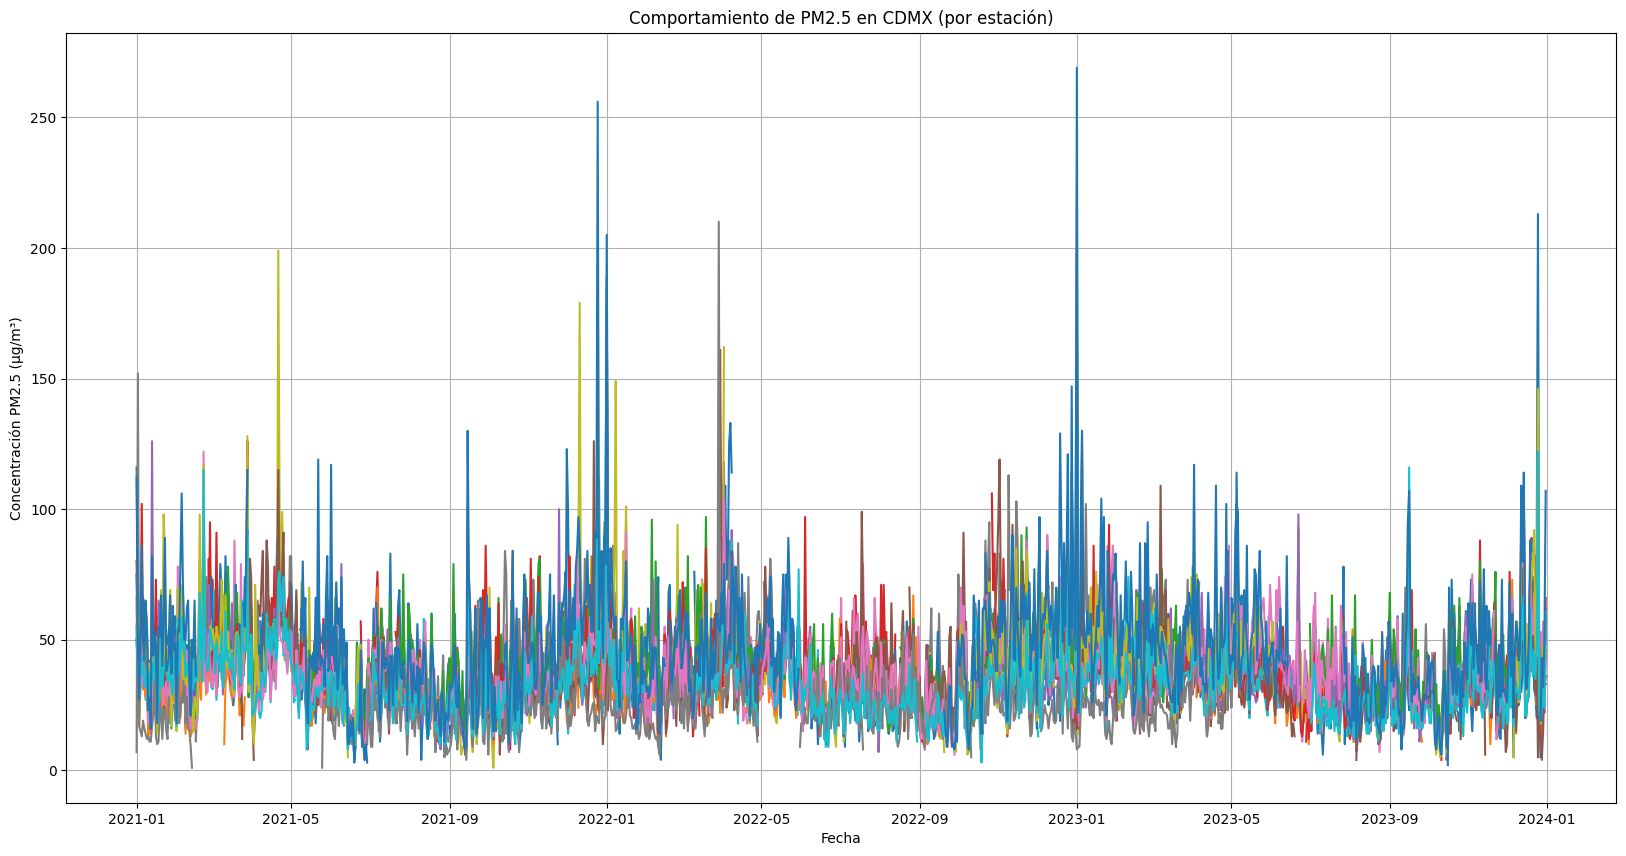

In [ ]:
fig,ax = plt.subplots(figsize=(20,10))
plt.plot(PM25)
plt.grid()
ax.set_xlabel("Fecha")
ax.set_ylabel("Concentración PM2.5 (µg/m³)")
ax.set_title("Comportamiento de PM2.5 en CDMX (por estación)")
plt.show()

In [ ]:
PM25max = PM25.max(axis=1)

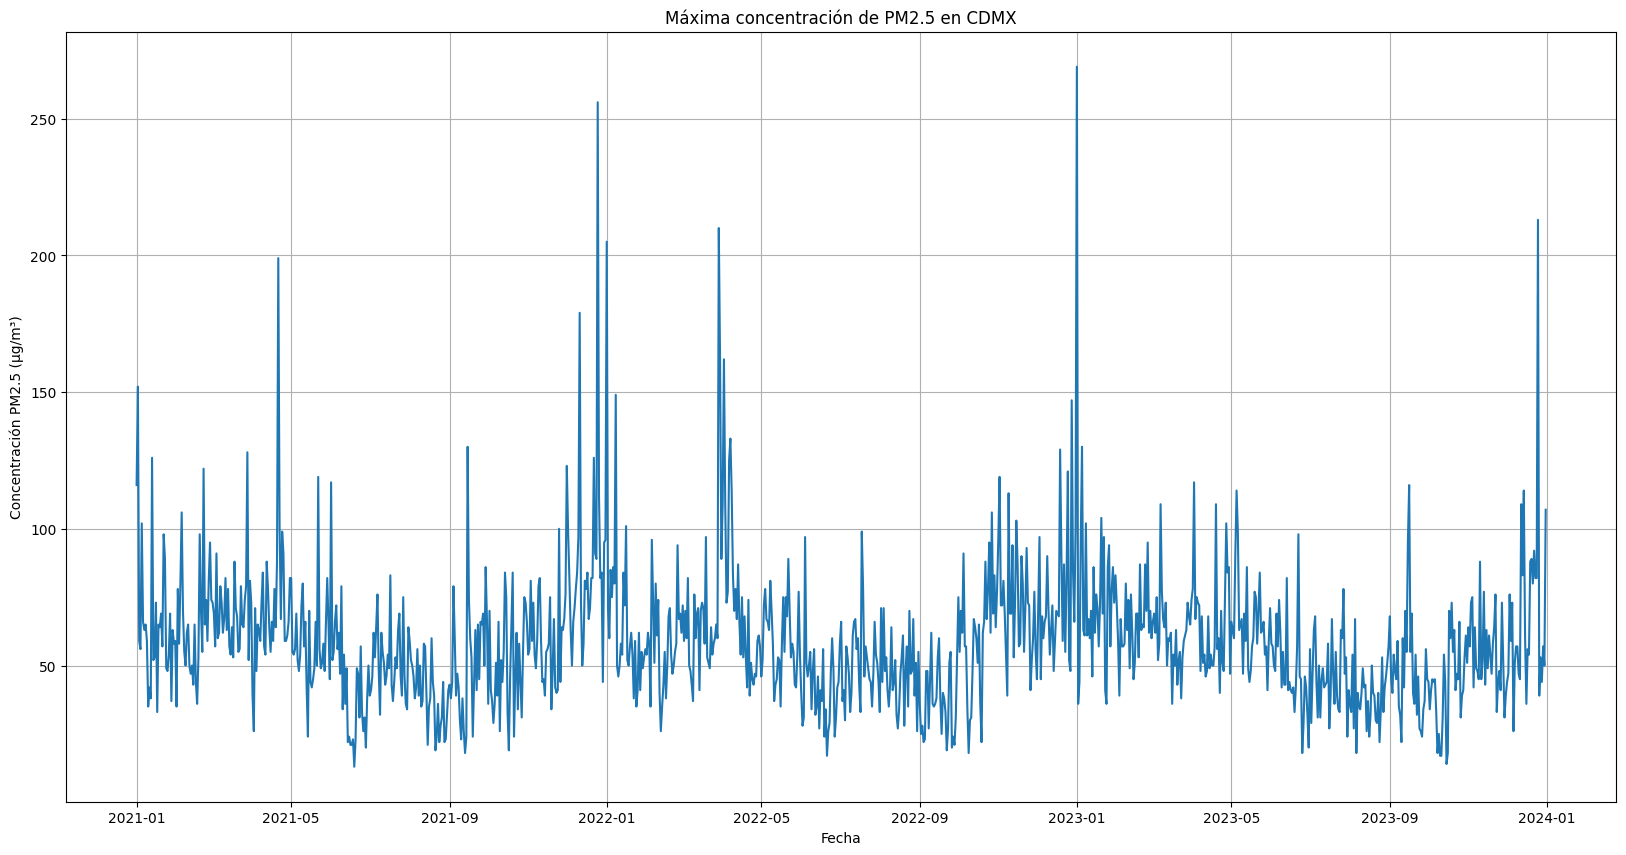

In [ ]:
fig,ax = plt.subplots(figsize=(20,10))
plt.plot(PM25max)
plt.grid()
ax.set_xlabel("Fecha")
ax.set_ylabel("Concentración PM2.5 (µg/m³)")
ax.set_title("Máxima concentración de PM2.5 en CDMX")
plt.show()

In [ ]:
PM25_rs = PM25max.resample("1d").mean()

In [ ]:
x = PM25_rs.copy()
y = PM25_rs.copy()

In [ ]:
X=pd.DataFrame(x)
X["t-1"] = X.shift(1)
for i in range(1,5):
  X["t-"+str(i+1)] = X["t-"+str(i)].shift(1)
X = X.iloc[:,1:]
X = X.dropna()
Y = y.iloc[5:]

In [ ]:
fecha = "2023-12-31"

Xtrain = X.loc[:fecha]
Xtest = X.loc[fecha:]
Ytrain = Y.loc[:fecha]
Ytest = Y.loc[fecha:]

In [ ]:
red = MLPRegressor(hidden_layer_sizes=(100,100), activation = "relu",max_iter = 10000)
red.fit(Xtrain,Ytrain)
red.score(X,Y)

0.37125586970274493

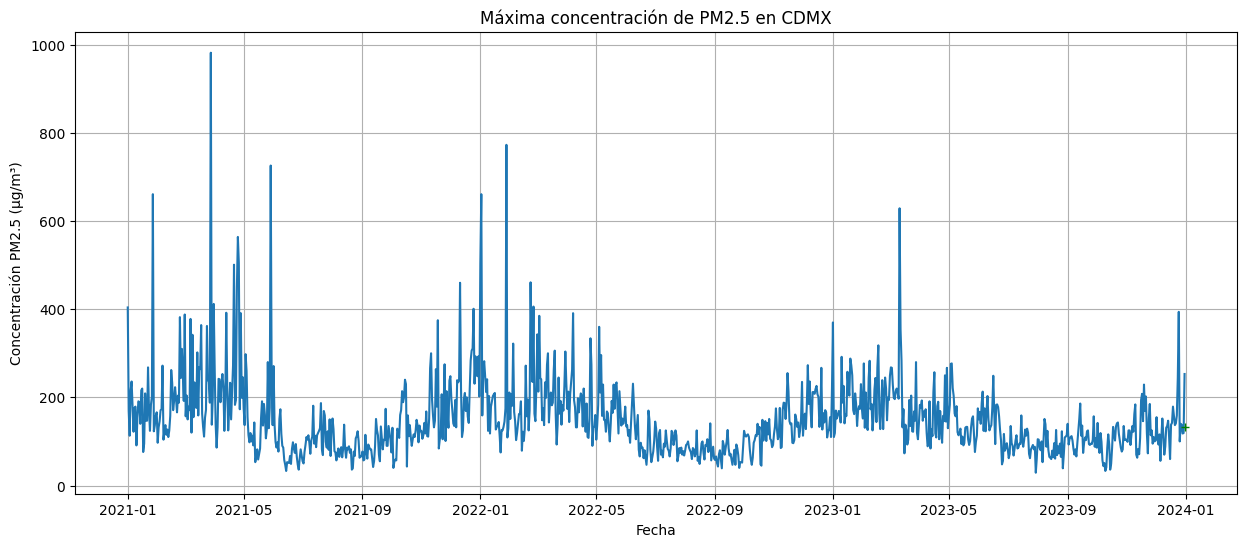

In [ ]:
fig, ax = plt.subplots(figsize=(15, 6))
plt.grid()
plt.plot(y)
plt.plot(Xtest.index,red.predict(Xtest),"g+")
ax.set_xlabel("Fecha")
ax.set_ylabel("Concentración PM2.5 (µg/m³)")
ax.set_title("Máxima concentración de PM2.5 en CDMX")
plt.show()

In [ ]:
n = 0
Xp = Xtrain.copy()
Xp = Xp.iloc[len(Xp.index)-1:len(Xp.index)]
while n<5:
  Xant = Xp.iloc[len(Xp.index)-1:len(Xp.index)]
  Xp1 = Xant.shift(1,axis=1)
  Xp1["t-1"] = red.predict(Xant)
  Xp1.index = Xant.index + pd.Timedelta(days=1)
  Xp = pd.concat([Xp,Xp1])
  n+=1

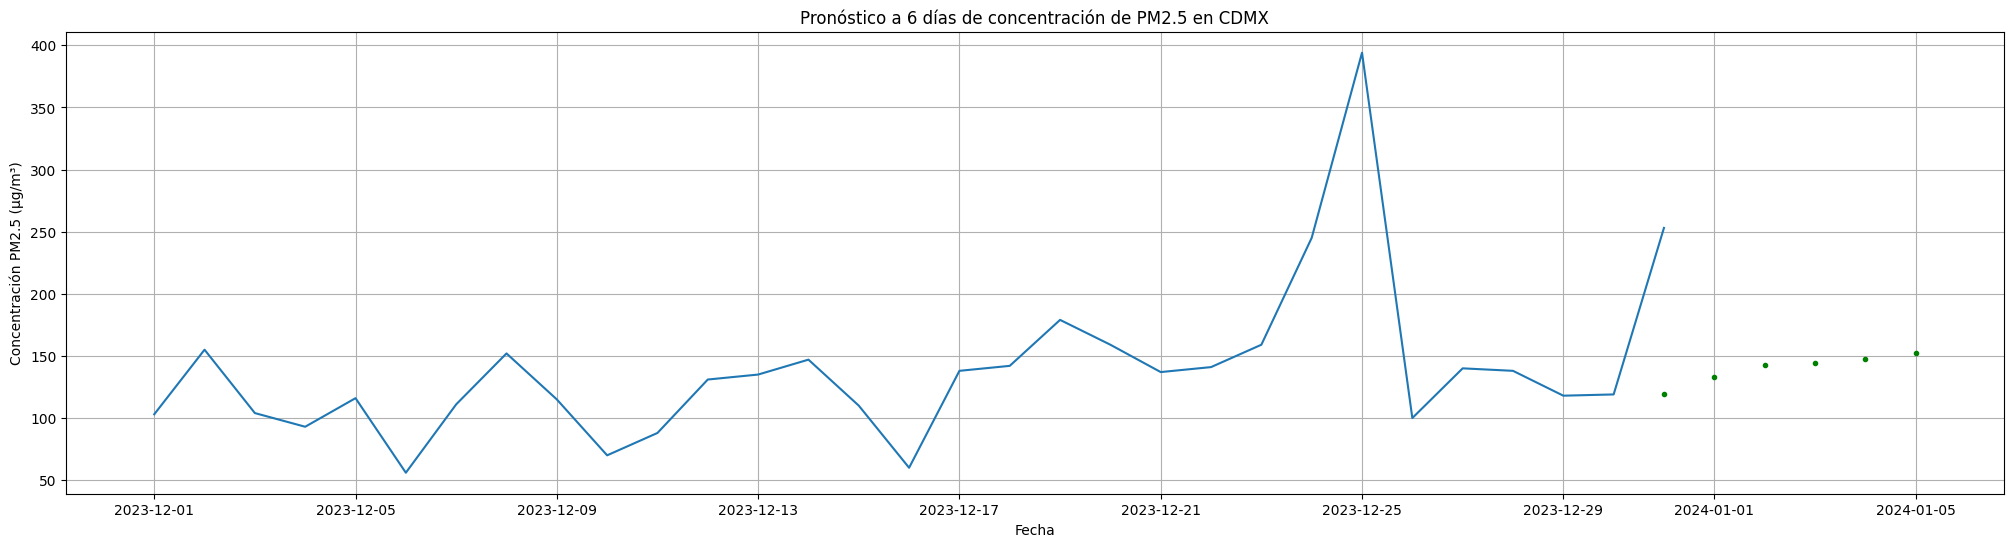

In [ ]:
fig, ax = plt.subplots(figsize=(25, 6))
plt.grid()
plt.plot(y["2023-12-01":"2024-01-28"])
plt.plot(Xp["2023-12-01":"2024-01-28"].index,Xp["2023-12-01":"2024-01-28"]["t-1"],"g.")
ax.set_xlabel("Fecha")
ax.set_ylabel("Concentración PM2.5 (µg/m³)")
ax.set_title("Pronóstico a 6 días de concentración de PM2.5 en CDMX")
plt.show()

In [ ]:
PM10 = pd.read_csv('Datos SINAICA-PM10-CH.csv',encoding = 'latin1')

In [ ]:
PM10 = PM10.iloc[:,1:]
PM10.index = PM10.iloc[:,0]
PM10.index = pd.to_datetime(PM10.index)
PM10 = PM10.iloc[:,3:53]
for col in PM10.columns:
    PM10[col] = PM10[col].replace(" - - - - ",np.nan)
    PM10[col] = pd.to_numeric(PM10[col], errors='coerce')

<ipython-input-274-543bd715be7f>:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  PM10[col] = PM10[col].replace(" - - - - ",np.nan)


In [ ]:
for col in PM10.columns[3:54]:
    if(PM10[col].sum()==0):
        PM10 = PM10.drop(col, axis=1)

In [ ]:
PM10 = PM10.groupby(PM10.index).max()

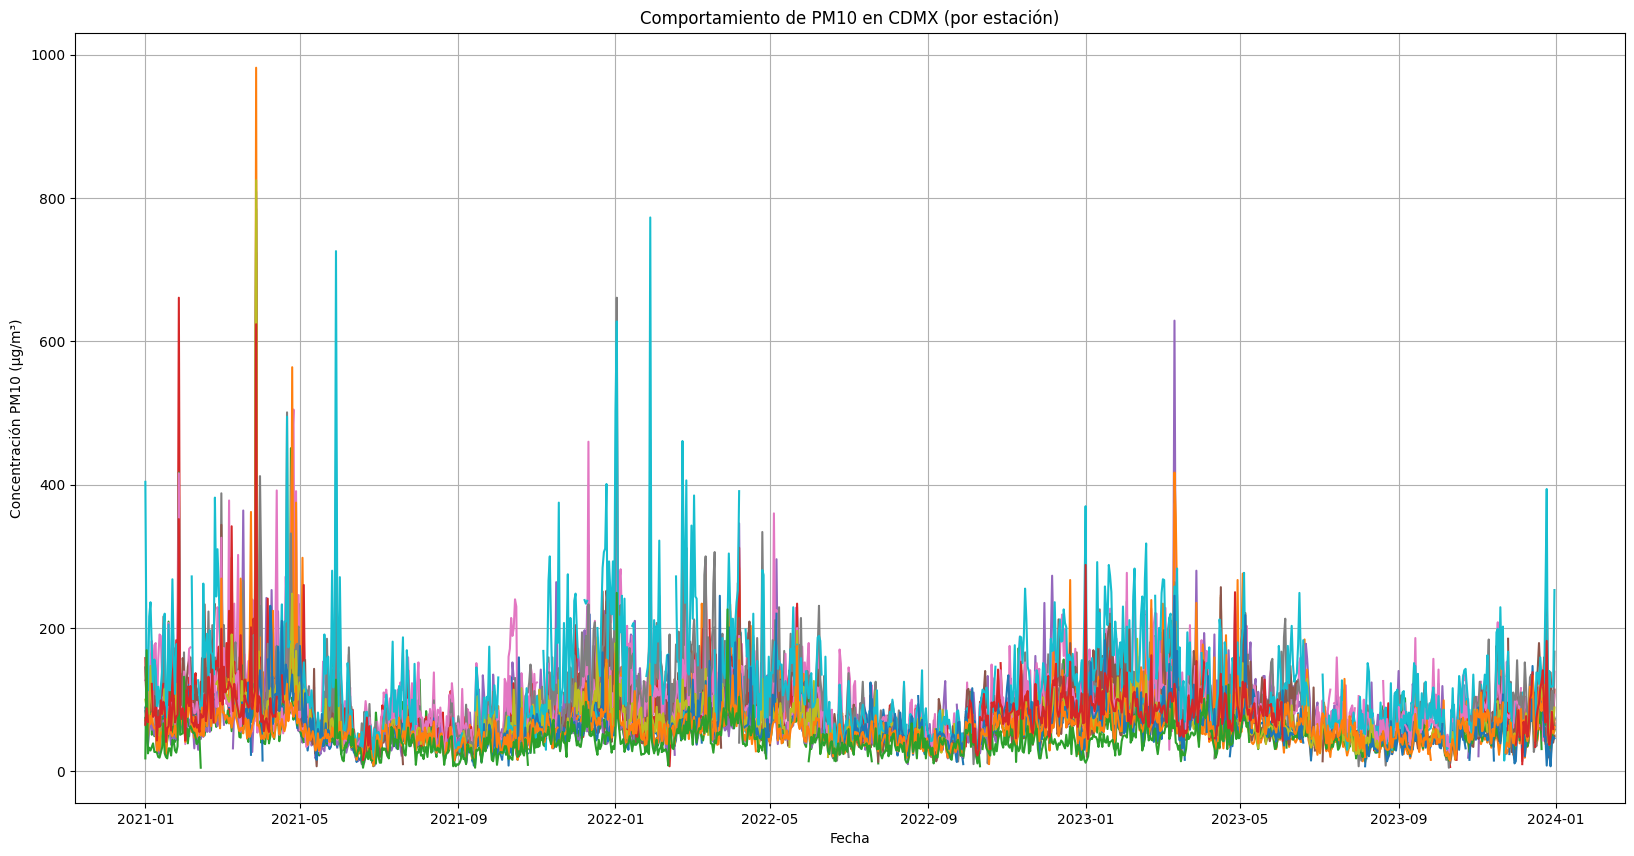

In [ ]:
fig,ax = plt.subplots(figsize=(20,10))
plt.plot(PM10)
plt.grid()
ax.set_xlabel("Fecha")
ax.set_ylabel("Concentración PM10 (µg/m³)")
ax.set_title("Comportamiento de PM10 en CDMX (por estación)")
plt.show()

In [ ]:
PM10max = PM10.max(axis=1)

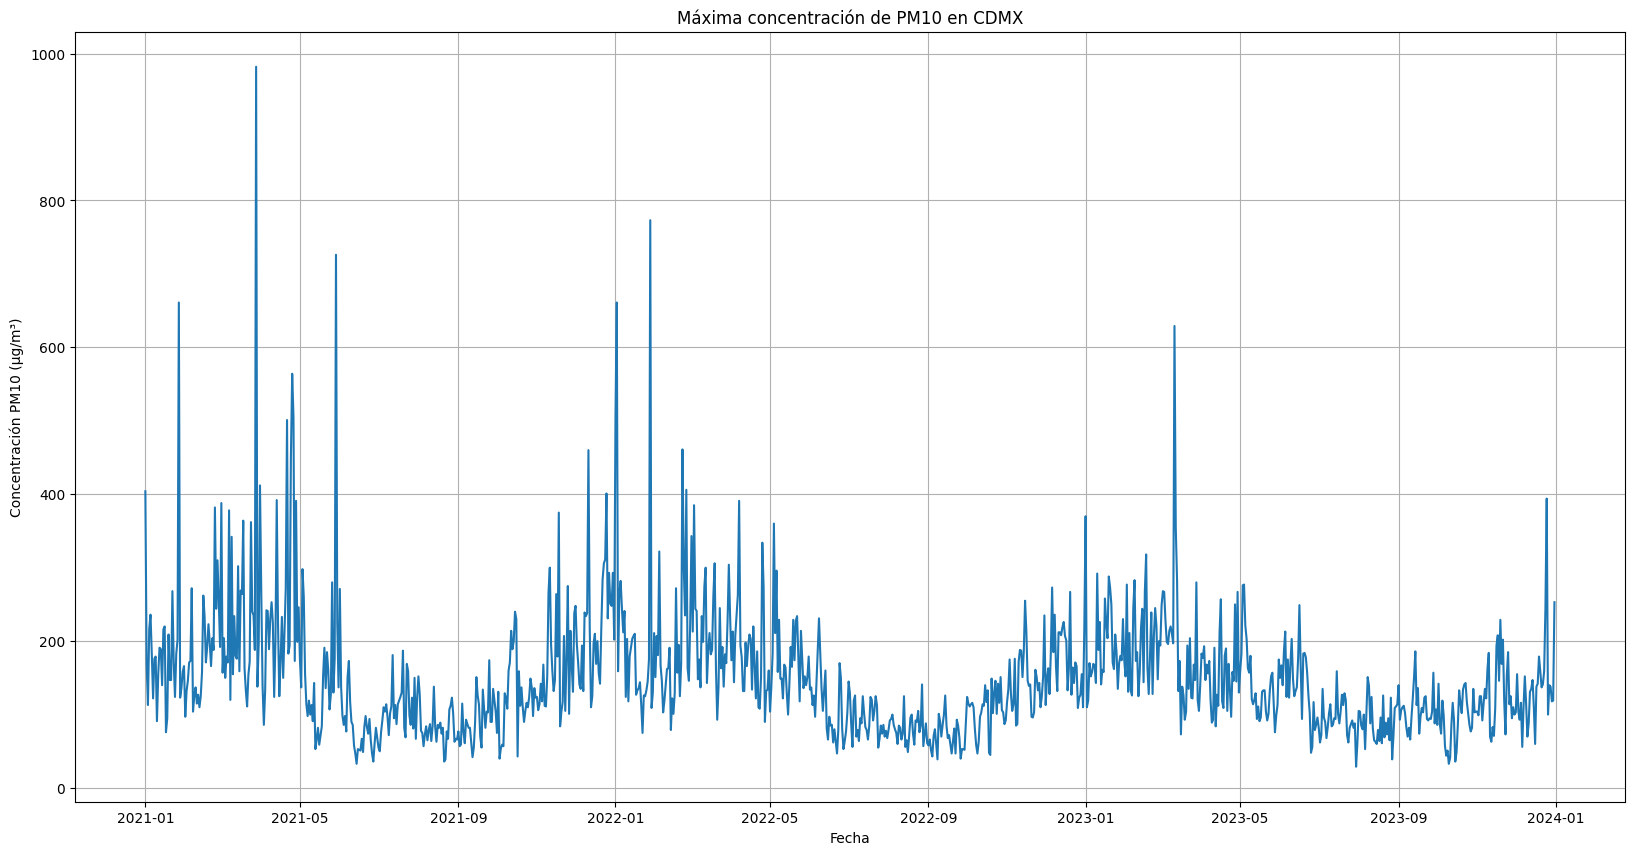

In [ ]:
fig,ax = plt.subplots(figsize=(20,10))
plt.plot(PM10max)
plt.grid()
ax.set_xlabel("Fecha")
ax.set_ylabel("Concentración PM10 (µg/m³)")
ax.set_title("Máxima concentración de PM10 en CDMX")
plt.show()

In [ ]:
PM10_rs = PM10max.resample("1d").mean()

In [ ]:
x = PM10_rs.copy()
y = PM10_rs.copy()

In [ ]:
X=pd.DataFrame(x)
X["t-1"] = X.shift(1)
for i in range(1,5):
  X["t-"+str(i+1)] = X["t-"+str(i)].shift(1)
X = X.iloc[:,1:]
X = X.dropna()
Y = y.iloc[5:]

In [ ]:
fecha = "2023-12-31"

Xtrain = X.loc[:fecha]
Xtest = X.loc[fecha:]
Ytrain = Y.loc[:fecha]
Ytest = Y.loc[fecha:]

In [ ]:
red = MLPRegressor(hidden_layer_sizes=(100,100), activation = "relu",max_iter = 10000)
red.fit(Xtrain,Ytrain)
red.score(X,Y)

0.4539456873792175

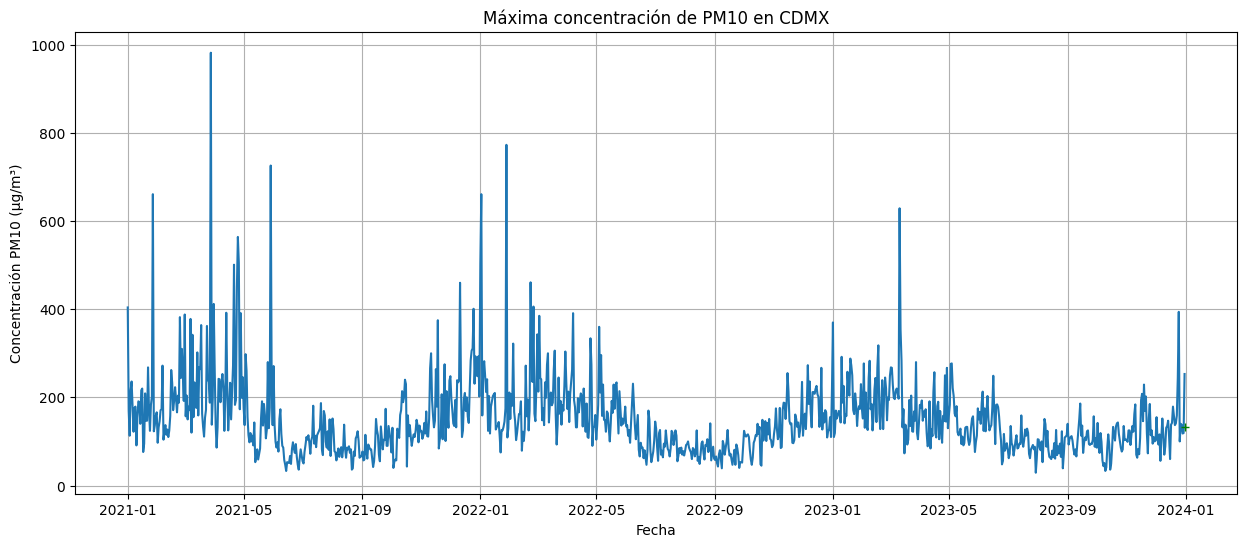

In [ ]:
fig, ax = plt.subplots(figsize=(15, 6))
plt.grid()
plt.plot(y)
plt.plot(Xtest.index,red.predict(Xtest),"g+")
ax.set_xlabel("Fecha")
ax.set_ylabel("Concentración PM10 (µg/m³)")
ax.set_title("Máxima concentración de PM10 en CDMX")
plt.show()

In [ ]:
n = 0
Xp = Xtrain.copy()
Xp = Xp.iloc[len(Xp.index)-1:len(Xp.index)]
while n<5:
  Xant = Xp.iloc[len(Xp.index)-1:len(Xp.index)]
  Xp1 = Xant.shift(1,axis=1)
  Xp1["t-1"] = red.predict(Xant)
  Xp1.index = Xant.index + pd.Timedelta(days=1)
  Xp = pd.concat([Xp,Xp1])
  n+=1

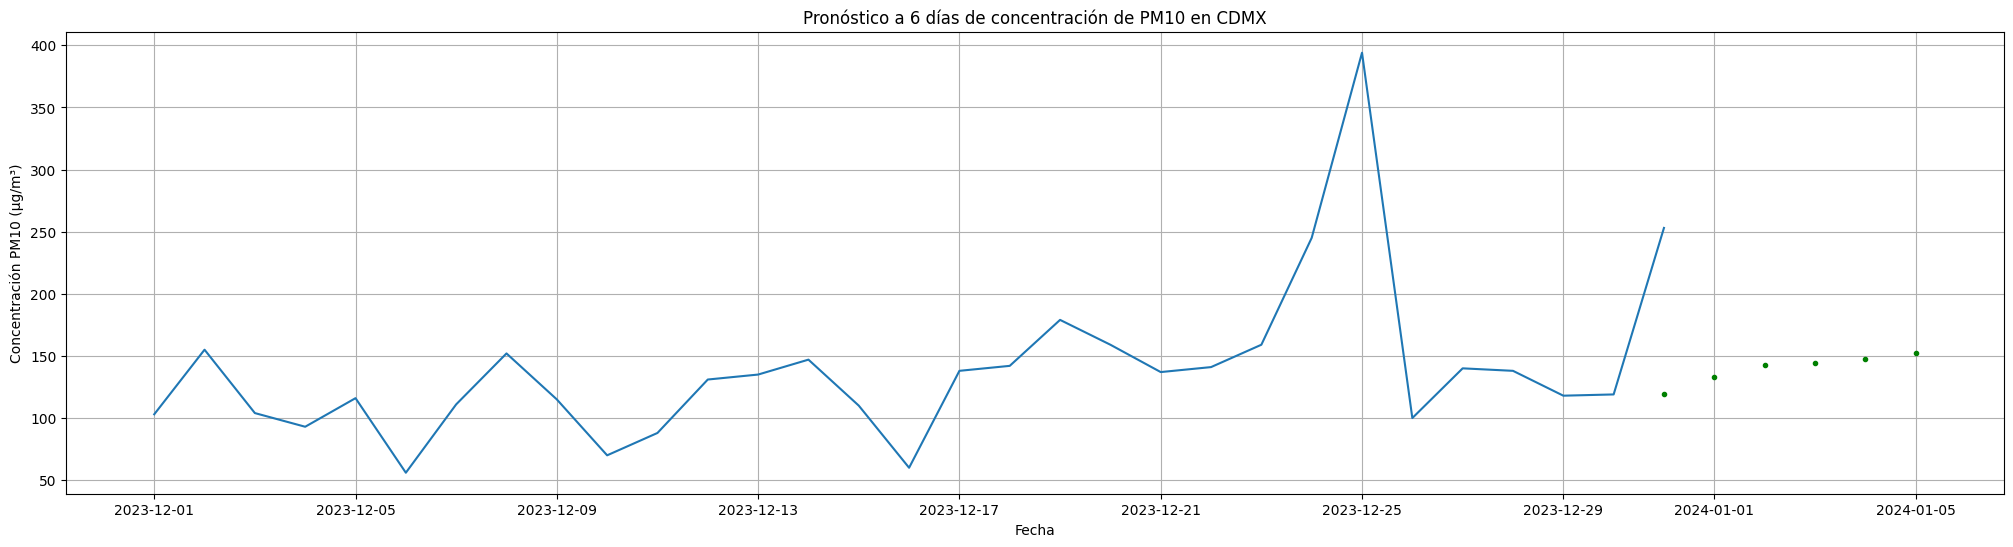

In [ ]:
fig, ax = plt.subplots(figsize=(25, 6))
plt.grid()
plt.plot(y["2023-12-01":"2024-01-28"])
plt.plot(Xp["2023-12-01":"2024-01-28"].index,Xp["2023-12-01":"2024-01-28"]["t-1"],"g.")
ax.set_xlabel("Fecha")
ax.set_ylabel("Concentración PM10 (µg/m³)")
ax.set_title("Pronóstico a 6 días de concentración de PM10 en CDMX")
plt.show()